In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
df = pd.read_csv(r"D:\Files\ecommerce_sales_data (2).csv").sort_values(by="Order Date")
df["Order Date"] = pd.to_datetime(df["Order Date"])


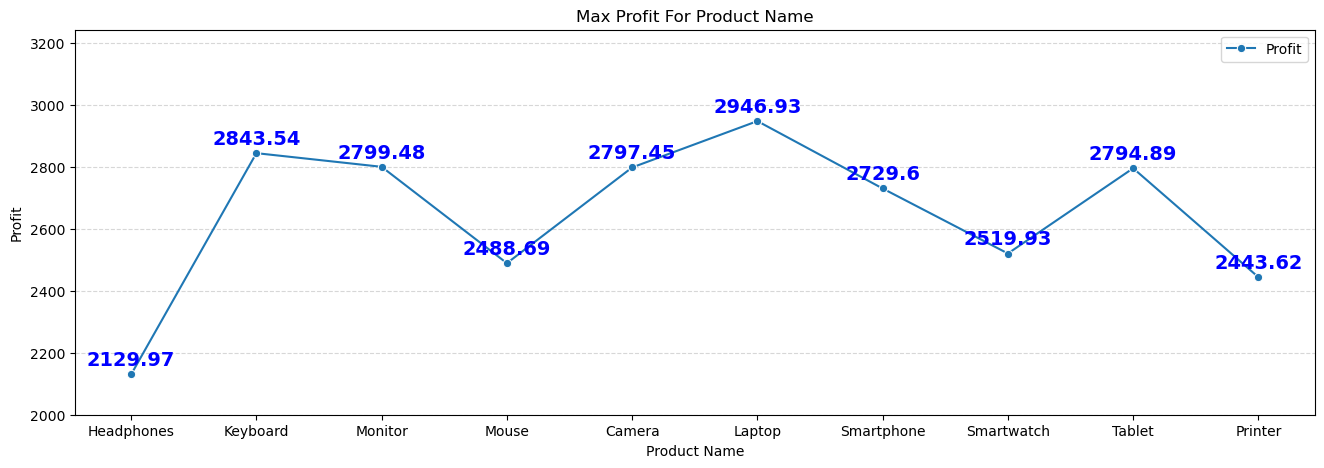

In [51]:
max_product = df.groupby(["Category","Product Name"])["Profit"].idxmax()
ele_product = df.loc[max_product]

plt.figure ( figsize = ( 16 , 5 ) ) 
sns.lineplot(data=ele_product,x="Product Name",y="Profit",label="Profit",marker="o")

for ind , vl in enumerate(ele_product["Profit"]):
    plt.text(ind,vl+15,vl,ha="center",va="bottom",color="blue",fontsize=14,fontweight='bold')
    
plt.ylim(2000,ele_product["Profit"].max()*1.10)
plt.title("Max Profit For Product Name")
plt.grid(axis='y', linestyle='--', alpha=0.5)

***الـ Laptop هو الملك هنا؛ محقق أعلى ربح ومعدي الـ 2946. ده معناه إن تركيز الشركة لازم يفضل عليه،***
***Mouse , HeadPhone , Printer منتجات محتاجه عرض خاص***
***باقي الانواع ربحها مستقر و قد تكون الاساس للمحل او الشركه***
***تخطي ربحيه اللاب توب لربحيه الهاتف المحمول قد يكون بسبب هامش الربح للهاتف او ميزات في اللاب***

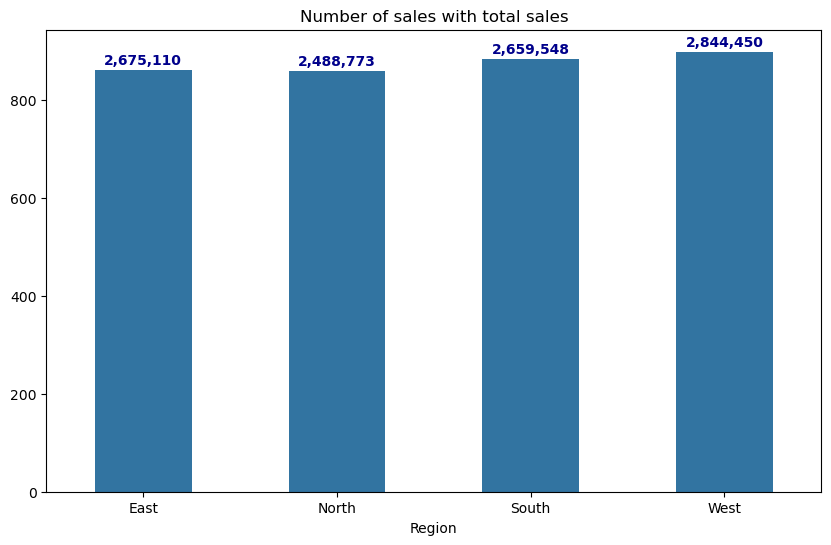

In [52]:
count_sales = df["Region"].value_counts().sort_index()
region_sales = df.groupby("Region")["Sales"].sum().sort_index()

plt.figure ( figsize = ( 10 , 6 ) )
plt.title ( "Number of sales with total sales" )
sns.barplot( x = count_sales.index , y = count_sales.values , width = 0.5 )

for i, count_val in enumerate(count_sales.values):
    money_label = region_sales.values[i]
    plt.text(i, count_val + 5, f'{money_label:,.0f}', 
             ha="center", va="bottom", color="darkblue", fontweight='bold')


<Axes: xlabel='Sales', ylabel='Profit'>

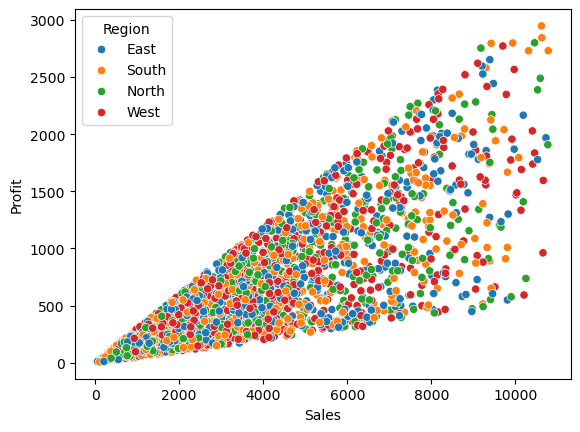

In [53]:
sns.scatterplot(x=df["Sales"],y=df["Profit"], hue=df["Region"])

***"هناك علاقة طردية قوية بين المبيعات والربح في جميع المناطق، ومع زيادة حجم المبيعات نلاحظ تشتتًا أكبر في هوامش الربح. تتميز منطقة South (باللون الأخضر) بتحقيق أعلى هوامش ربح في الصفقات الكبرى، بينما تتركز مبيعات منطقة West (باللون الأحمر) في مستويات ربح أقل رغم ارتفاع حجم مبيعاتها."***

Text(0.5, 0, 'Timeline')

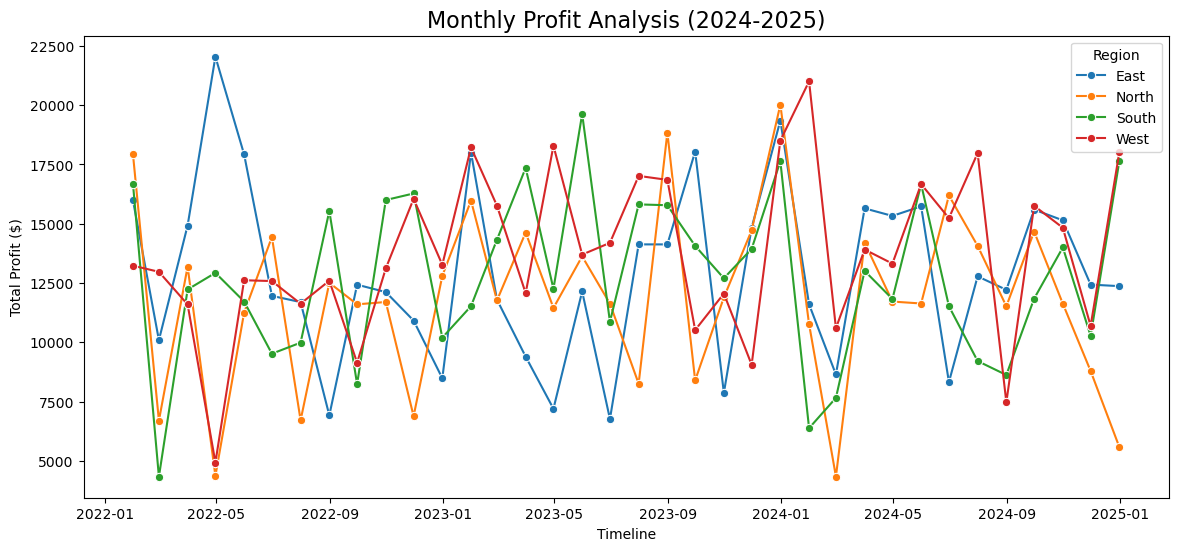

In [54]:

monthly_region_profit = df.groupby(['Region', pd.Grouper(key='Order Date', freq='ME')])['Profit'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_region_profit, x='Order Date', y='Profit', hue='Region', marker='o')

plt.title('Monthly Profit Analysis (2024-2025)', fontsize=16)
plt.ylabel('Total Profit ($)')
plt.xlabel('Timeline')

<Axes: xlabel='Quantity', ylabel='Count'>

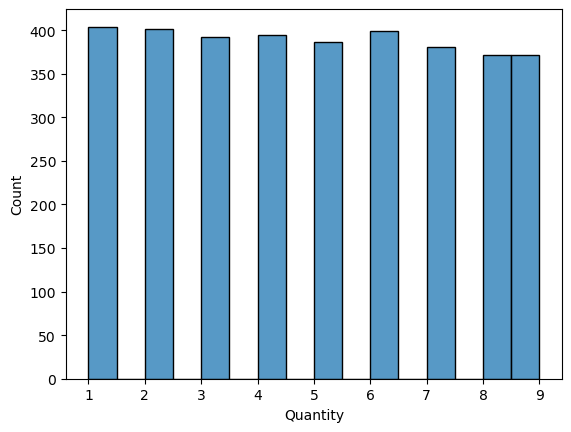

In [55]:
sns.histplot(x=df["Quantity"],fill=True)

# ***لا يوجد تفضيل محدد للعملاء لعدد قطع معين في الطلبية الواحدة، حيث يتم توزيع المبيعات بشكل متساوٍ تقريباً على جميع الكميات من 1 إلى 9.***

# *"الخلاصة: المشروع أظهر أن حجم المبيعات ليس العامل الوحيد للربحية، حيث تفوقت منطقة South في كفاءة الهوامش رغم أن منطقة West تمتلك حجم مبيعات ضخم. نوصي بتقليل الخصومات في المنطقة الغربية ومراقبة تراجع الأرباح الجماعي الذي يحدث في شهر مايو من كل عام."*